In [9]:
# General imports
from functools import partial

import numpy as np
import numpy.typing as npt
import jax.numpy as jnp
from jax.typing import ArrayLike

import matplotlib.pyplot as plt
import matplotlib.cm as cm
params = {'text.usetex': False, 'mathtext.fontset': 'cm'}
plt.rcParams.update(params)

# SWIM-PDE imports
from swimpde_jax.domain import MultiLevelDecomposedDomain
from swimpde_jax.solver import DomainDecomposedStaticSolver
from swimpde_jax.boundary import ZeroDirichlet
from swimpde_jax.ansatz import DecomposedBasicAnsatz
from swimpde_jax.equation import Laplacian
from swimpde_jax.utils import normalized_l1_loss

# Multilevel FBPINN imports
from fbpinns.util.logger import logger
from fbpinns.networks import FCN
logger.setLevel("CRITICAL")

from fbpinns.multilevel_paper.problems import Laplace2D_multiscale
from fbpinns.multilevel_paper.plot import exact_solution, FBPINN_solution
from fbpinns.multilevel_paper.plot import load_FBPINN as load_FBPINN_

### Multiscale Laplacian 2D Weak Scaling Experiment

In [ ]:
# General definitions
problem = Laplace2D_multiscale
tag = "weak"# test type
max_config = 3# maximum configuration to be run starting from 1 up to defined
n_seeds = 10# number of run per configuration
overlapping_ratio = 1.9

In [11]:
# SWIM-PDE related implementations
def multiscale_laplacian_target(x: npt.ArrayLike, n_basis: int) -> npt.ArrayLike:
    """ Analytical solution definition."""
    coeffs = 2 ** np.arange(1, n_basis + 1)
    sin_x1 = np.sin(np.outer(coeffs, np.pi * x[:, 0]))  
    sin_x2 = np.sin(np.outer(coeffs, np.pi * x[:, 1]))  

    solution = np.sum(sin_x1 * sin_x2, axis=0)  
    return ((1 / n_basis) * solution)[:, None]

def laplacian_forcing(x: npt.ArrayLike, n_basis: int) -> npt.ArrayLike:
    """ Source function definition."""
    coeffs = 2 ** np.arange(1, n_basis + 1)  
    omega_pi_squared = (coeffs * np.pi) ** 2  
    sin_x1 = np.sin(np.outer(coeffs, np.pi * x[:, 0]))  
    sin_x2 = np.sin(np.outer(coeffs, np.pi * x[:, 1])) 

    forcing = np.sum(omega_pi_squared[:, None] * sin_x1 * sin_x2, axis=0)  
    return ((2 / n_basis) * forcing)[:, None]

def constraining_operator(points: ArrayLike, sigma=0.2) -> ArrayLike:
    """
    [Cu](x) = tanh(x1/σ) tanh((1−x1)/σ) tanh(x2/σ) tanh((1−x2)/σ)
    """
    x, y = points[0], points[1]
    return (
        jnp.tanh(x / sigma) *
        jnp.tanh((1 - x) / sigma) *
        jnp.tanh(y / sigma) *
        jnp.tanh((1 - y) / sigma)
    )

def load_SWIMPDEs(solver, inputs, true_sol, model, tag, problem, partition, overlap_ratio, num_basis, n_seeds):
    """Loads SWIMPDE base models over multiple seeds and returns avarage losses / times"""
    ts, l1ns = [], []
    for seed in range(n_seeds):
        file_name = f"{model}_{tag}_{problem.__name__}_{str(partition).replace(' ', '')}-levels_{overlap_ratio}-overlap_{num_basis}-basis_{seed}"
        file_path = f"./results/swimpde/{file_name}"
        solver = solver.load(file_path)
        predictions, _, _ = solver.evaluate(inputs)
        l1n = normalized_l1_loss(predictions, true_sol)
        t = solver._info["fit"]["seconds"]
        ts.append(t); l1ns.append(l1n)

    #ts = np.asarray(ts); l1ns = np.asarray(l1ns)
    ts, l1ns = np.asarray(ts)[:, None], np.asarray(l1ns)[:, None]
    t_mu, t_sd, t_mi, t_ma = ts.mean(axis=0), ts.std(axis=0), ts.min(axis=0), ts.max(axis=0)
    l1_mu, l1_sd, l1_mi, l1_ma = l1ns.mean(axis=0), l1ns.std(axis=0), l1ns.min(axis=0), l1ns.max(axis=0)
    i = np.array([1])  # single training step
    print(l1ns.shape, l1ns[-1].min(), l1ns[-1].max(), ts[-1].min(), ts[-1].max(), file_name)
    return solver, predictions, i, (t_mu, t_sd, t_mi, t_ma), (l1_mu, l1_sd, l1_mi, l1_ma)


swim_models = ["Frozen-PINN-swim-MLDD", "Frozen-PINN-elm-MLDD"]
swim_num_basis={"Frozen-PINN-swim-MLDD": 32, "Frozen-PINN-elm-MLDD": 32}
swim_activation="tanh"
swim_param_samplers = {"Frozen-PINN-swim-MLDD": "tanh", "Frozen-PINN-elm-MLDD": "random"}
swim_svd_cutoff= 1e-10
swim_regularization_scale = 1e-10
swim_window_fn = "gaussian"
swim_solver = "lstsq"
swim_use_disk = False

swim_problem_configs = {
    1 : {"num_sin_basis": 1, "num_train_point_per_dim":20, "num_test_point_per_dim": 350, "partition": [1, 2]},
    2 : {"num_sin_basis": 2, "num_train_point_per_dim":40, "num_test_point_per_dim": 350, "partition": [1, 2, 4]},
    3 : {"num_sin_basis": 3, "num_train_point_per_dim":80, "num_test_point_per_dim": 350, "partition": [1, 2, 4, 8]},
    4 : {"num_sin_basis": 4, "num_train_point_per_dim":160, "num_test_point_per_dim": 350, "partition": [1, 2, 4, 8, 16]},
    5 : {"num_sin_basis": 5, "num_train_point_per_dim":320, "num_test_point_per_dim": 350, "partition": [1, 2, 4, 8, 16, 32]},
    6 : {"num_sin_basis": 6, "num_train_point_per_dim":640, "num_test_point_per_dim": 350, "partition": [1, 2, 4, 8, 16, 32, 64]},
}


span = (
        [0, 0], # mins along each axes
        [1, 1] # maxs along each axes
    )

n_dim = len(span)

In [12]:
# Multiscale FBPINN related implementations
def load_FBPINN(tag, problem, network, l, w, h, p, n, lr, n_seeds):
    "Loads FBPINNs over multiple seeds, and returns average losses / times"
    ts, l1ns = [],[]
    for seed in range(n_seeds):
        c, model, i, t, l1n = load_FBPINN_(tag, problem, network, l, w, h, p, n, lr, seed)
        ts.append(t); l1ns.append(l1n)
    ts, l1ns = np.stack(ts, axis=1), np.stack(l1ns, axis=1)
    t_mu, t_sd, t_mi, t_ma = ts.mean(axis=1), ts.std(axis=1), ts.min(axis=1), ts.max(axis=1)
    l1_mu, l1_sd, l1_mi, l1_ma = l1ns.mean(axis=1), l1ns.std(axis=1), l1ns.min(axis=1), l1ns.max(axis=1)
    print(i[-1], l1ns.shape, l1ns[-1].min(), l1ns[-1].max(), ts[-1].min(), ts[-1].max(), c.run)
    return c, model, i, (t_mu, t_sd, t_mi, t_ma), (l1_mu, l1_sd, l1_mi, l1_ma)

In [13]:
# Plot related implementations
def plot_l1(i, l1s, label=None, marker=None, color=None, s=None, lw=None):
    l1_mu, _, l1_mi, l1_ma = l1s
    plt.plot(i, l1_mu, label=label, c=color, lw=lw)
    plt.fill_between(i, l1_mi, l1_ma, lw=0, color=color, alpha=0.2)
    if marker is not None:
        plt.scatter(i[-1], l1_mu[-1], marker=marker, edgecolors="none", facecolors=color, s=s)

def scatter_l1(ts, l1s, label=None, marker=None, color=None, s=None, lw=None):
    (t_mu, _, t_mi, t_ma), (l1_mu, _, l1_mi, l1_ma) = ts, l1s
    plt.errorbar(t_mu[-1], l1_mu[-1], 
                 xerr=np.array([[t_mu[-1]-t_mi[-1]],[t_ma[-1]-t_mu[-1]]]),
                 yerr=np.array([[l1_mu[-1]-l1_mi[-1]],[l1_ma[-1]-l1_mu[-1]]]),
                 ecolor=color,
                 marker=marker,
                 markeredgecolor="none",
                 markerfacecolor=color,
                 label=label,
                 markersize=s,
                 lw=0,
                 elinewidth=lw)

def fix_plot(legend=True):
    if legend:
        plt.legend()
    plt.yscale("log")
    plt.xlabel("Training step", fontsize="x-large")
    plt.ylabel("Normalised L1 test loss", fontsize="x-large")

def fix_plot3(legend=True):
    if legend:
        plt.legend()
    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel("Total time elapsed (s)", fontsize="x-large")
    plt.ylabel("Normalised L1 test loss", fontsize="x-large")

def fix_plot2():
    plt.xlabel("$x_1$", fontsize="x-large")
    plt.ylabel("$x_2$", fontsize="x-large")
    plt.xlim(0,1); plt.ylim(0,1)
    
def fix_plot4():
    plt.xticks([]); plt.yticks([])
    plt.xlim(0,1); plt.ylim(0,1)

def savefig(tag2="", format="pdf"):
    plt.savefig(f"plots/{problem.__name__}-{tag}{tag2}.{format}", format=format, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")

colors1 = cm.Blues(np.linspace(0.2,0.95,6))
colors2 = cm.Greens(np.linspace(0.2,0.95,6))
colors3 = cm.Reds(np.linspace(0.2,0.95,6))
colors4 = cm.Greys(np.linspace(0.2,0.95,6))
colors5 = cm.Purples(np.linspace(0.2,0.95,6))
colorss = [colors1, colors2, colors3, colors4, colors5]

### Final plot loop

FBPINN_weak_Laplace2D_multiscale_FCN_[1, 2]-levels_1.9-overlap_1-layers_16-hidden_20-n_0.001-lr-0
50000.0 (101, 1) 2.081817902218201e-05 2.081817902218201e-05 279.41058468818665 279.41058468818665 FBPINN_weak_Laplace2D_multiscale_FCN_[1, 2]-levels_1.9-overlap_1-layers_16-hidden_20-n_0.001-lr-0
FBPINN_weak_Laplace2D_multiscale_FCN_[1, 2]-levels_1.9-overlap_1-layers_16-hidden_20-n_0.001-lr-0
50000.0 (101, 1) 2.081817902218201e-05 2.081817902218201e-05 279.41058468818665 279.41058468818665 FBPINN_weak_Laplace2D_multiscale_FCN_[1, 2]-levels_1.9-overlap_1-layers_16-hidden_20-n_0.001-lr-0
FBPINN_weak_Laplace2D_multiscale_FCN_[1, 2, 4]-levels_1.9-overlap_1-layers_16-hidden_40-n_0.001-lr-0
50000.0 (101, 1) 0.000283070755622532 0.000283070755622532 975.6413173675537 975.6413173675537 FBPINN_weak_Laplace2D_multiscale_FCN_[1, 2, 4]-levels_1.9-overlap_1-layers_16-hidden_40-n_0.001-lr-0
FBPINN_weak_Laplace2D_multiscale_FCN_[1, 2, 4]-levels_1.9-overlap_1-layers_16-hidden_40-n_0.001-lr-0
50000.0 (101

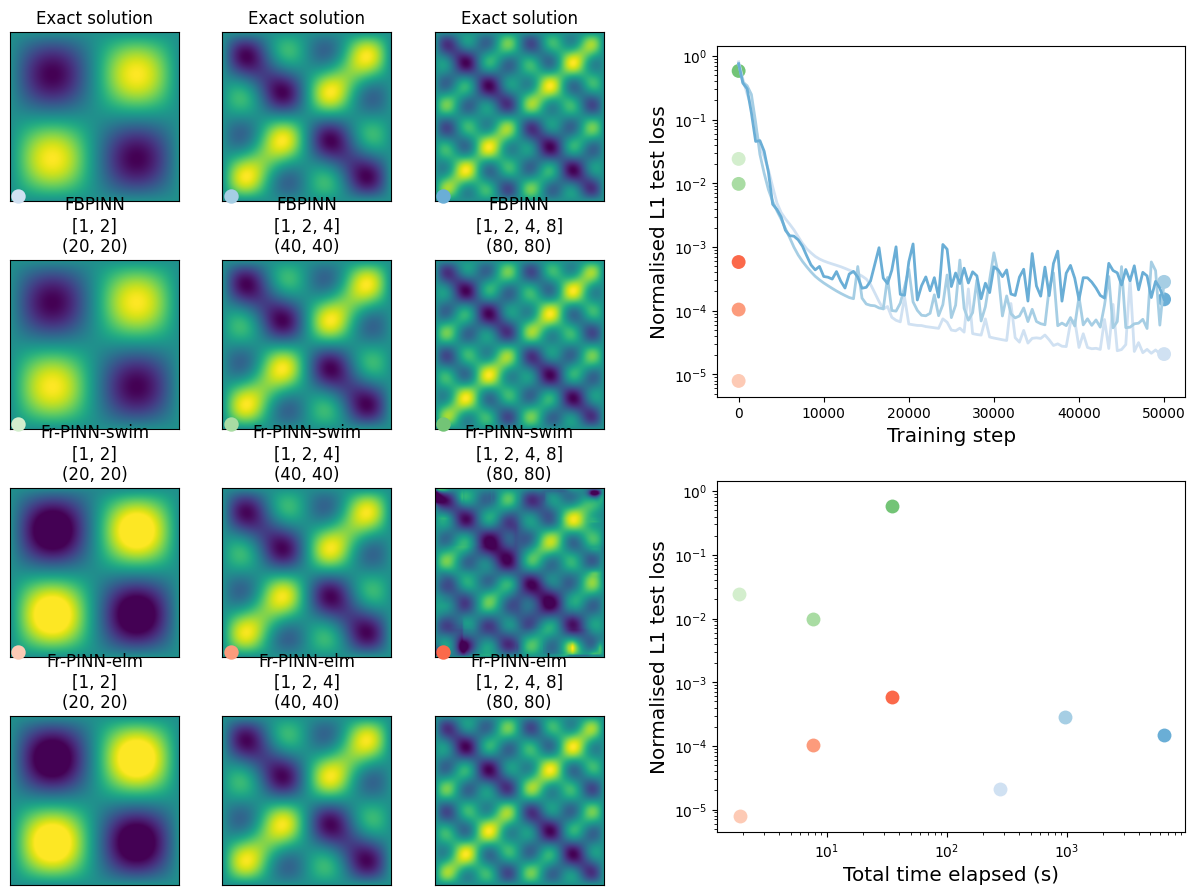

In [ ]:
summary = {}

### Multilevel FBPINN related implementation
lr = 1e-3# learning rate
h=1
w=1.9
p=16

ls=[2, 3, 4, 5, 6, 7][:max_config]# number of levels
ns=[(20,20),(40,40),(80,80),(160,160),(320,320),(640,640)][:max_config]

f = plt.figure(figsize=0.78*np.array([20,18]))
shape = (5,7)
# left, bottom, width, height
ax1 = f.add_axes([0.505,0.62,0.25,0.25])
ax2 = f.add_axes([0.505,0.31,0.25,0.25])
lx,ly=0.05,1.38

model_summary = []
ref_fd_sols_for_swims = dict()
for ip,(l_,n) in enumerate(zip(ls, ns)):
    l = [2**i for i in range(l_)]
    times_and_losses_dict = {}

    # get exact solution
    network = FCN
    h,p = 1,16
    c, model, i, ts, l1s = load_FBPINN(tag, problem, network, l, w, h, p, n, lr, n_seeds)
    u_exact = exact_solution(c, model)
    ref_fd_sols_for_swims[str(l)] = u_exact #store exact solution for SWIM as reference

    # plot exact solution
    plt.subplot2grid(shape, (0,ip))
    im = plt.imshow(u_exact.T, origin="lower", extent=(0,1,0,1))
    plt.title("Exact solution", fontsize="large")
    fix_plot4()

    for ir,(network, h, p, label, marker, ic) in enumerate([
        (FCN, 1, 16, f"FBPINN\n{l}\n{n}", "o",0),
    ]):

        # load solution
        if "FBPINN" in label:
            c, model, i, ts, l1s = load_FBPINN(tag, problem, network, l, w, h, p, n, lr, n_seeds)
            t_mu, t_sd, t_mi, t_ma = ts
            l1_mu, l1_sd, l1_mi, l1_ma = l1s
            times_and_losses_dict["t_mu"] = float(t_mu[-1])
            times_and_losses_dict["t_sd"] = float(t_sd[-1])
            times_and_losses_dict["l1_mu"] = float(l1_mu[-1])
            times_and_losses_dict["l1_sd"] = float(l1_sd[-1])
            times_and_losses_dict["num_basis"] = p

            u_test = FBPINN_solution(c, model)
        else:
            raise RuntimeError("Unexpected model.")
        level_summary_dict = {str(l): times_and_losses_dict}
        

        # plot convergence
        plt.sca(ax1)
        plot_l1(i, l1s, marker=marker, color=colorss[ic][ip], s=100, lw=2)
        plt.sca(ax2)
        scatter_l1(ts, l1s, marker=marker, color=colorss[ic][ip], s=10, lw=2)

        # plot solution
        plt.subplot2grid(shape, (1+ir,ip))
        plt.imshow(u_test.T, origin="lower", extent=(0,1,0,1), vmin=im.get_clim()[0], vmax=im.get_clim()[1])
        plt.scatter(lx,ly, clip_on=False, marker=marker, facecolor=colorss[ic][ip], s=70, lw=2)
        plt.title(label, fontsize="large")
        fix_plot4()

    model_summary.append(level_summary_dict)
summary = {"FBPINN": model_summary}

### SWIMPDE related implementation
swim_plot_specs = [
    (swim_models[0], "o", 1),
    (swim_models[1],  "o", 2),
]
swim_row0 = 2
for si, (swim_model, marker, ic) in enumerate(swim_plot_specs):
    model_summary = []
    for ip, config in enumerate(range(1, max_config + 1)):
        times_and_losses_dict = {}
        num_sin_basis = swim_problem_configs[config]['num_sin_basis']
        partition = swim_problem_configs[config]['partition']
        num_points_per_dim_train = swim_problem_configs[config]['num_train_point_per_dim']
        num_points_per_dim_test = swim_problem_configs[config]['num_test_point_per_dim']

        # Dataset Creation
        x_train = np.linspace(span[0][0], span[1][0],  num_points_per_dim_train)
        y_train = np.linspace(span[0][1], span[1][1],  num_points_per_dim_train)
        train_inputs = np.stack(np.meshgrid(x_train, y_train), axis=-1).reshape(-1, n_dim)

        x_test = np.linspace(span[0][0], span[1][0],  num_points_per_dim_test)
        y_test = np.linspace(span[0][1], span[1][1],  num_points_per_dim_test)
        test_inputs = np.stack(np.meshgrid(x_test, y_test), axis=-1).reshape(-1, n_dim)

        # True solution for plotting
        true_solution = ref_fd_sols_for_swims[str(partition)].reshape(-1)[:, None]

        # Domain Definition
        boundary_mask = (
            (test_inputs[:, 0] == span[0][0]) |
            (test_inputs[:, 0] == span[1][0]) |
            (test_inputs[:, 1] == span[0][1]) |
            (test_inputs[:, 1] == span[1][1])  
        )

        domain = MultiLevelDecomposedDomain(
            interior_points=test_inputs[~boundary_mask],
            boundary_points=test_inputs[boundary_mask],
            num_partition_per_level=partition,
            overlap_ratio=overlapping_ratio, 
            window_fn=swim_window_fn,
        )

        # Equation Definition
        equation = Laplacian()
    
        # Forcing function definition
        forcing_function = partial(laplacian_forcing, n_basis=num_sin_basis)

        # Boundary condition definition
        boundary_condition = ZeroDirichlet()
    
    
        # Ansatz definition 
        ansatz = DecomposedBasicAnsatz(
            n_basis=swim_num_basis[swim_model],
            activation=swim_activation,
            svd_cutoff=swim_svd_cutoff,
            constraining_operator=partial(constraining_operator, sigma=1/(2**num_sin_basis)),
            parameter_sampler=swim_param_samplers[swim_model],
        )

        # Solver definition
        solver = DomainDecomposedStaticSolver(
            domain=domain,
            ansatz=ansatz,
            boundary_condition=boundary_condition,
            equation=equation,
            f=forcing_function, 
            regularization_scale=swim_regularization_scale,
            solver=swim_solver,
            use_disk=swim_use_disk,
        )

        # Load models
        solver, test_pred, i, ts, l1s = load_SWIMPDEs(solver, test_inputs, true_solution, swim_model, tag, problem, partition, overlapping_ratio, swim_num_basis[swim_model], n_seeds)
        t_mu, t_sd, t_mi, t_ma = ts
        l1_mu, l1_sd, l1_mi, l1_ma = l1s
        times_and_losses_dict["t_mu"] = float(t_mu[-1])
        times_and_losses_dict["t_sd"] = float(t_sd[-1])
        times_and_losses_dict["l1_mu"] = float(l1_mu[-1])
        times_and_losses_dict["l1_sd"] = float(l1_sd[-1])
        times_and_losses_dict["num_basis"] = swim_num_basis[swim_model]
        level_summary_dict = {str(partition): times_and_losses_dict}
        model_summary.append(level_summary_dict)
        
        pred = test_pred.reshape(num_points_per_dim_test, num_points_per_dim_test)

        # plot convergence
        plt.sca(ax1)
        plot_l1(i, l1s, marker=marker, color=colorss[ic][ip], s=100, lw=2)
        plt.sca(ax2)
        scatter_l1(ts, l1s, marker=marker, color=colorss[ic][ip], s=10, lw=2)

        plt.subplot2grid(shape, (swim_row0 + si, ip))
        # Match color range to the exact solution of this config
        #vmin, vmax = u_exact_swim.min(), u_exact_swim.max()
        plt.imshow(pred.T, origin="lower", extent=(0, 1, 0, 1), vmin=im.get_clim()[0], vmax=im.get_clim()[1])
        plt.scatter(lx, ly, clip_on=False, marker=marker, facecolor=colorss[ic][ip], s=70, lw=2)
        plt.title(f"{swim_model[:-5][0:2]+ swim_model[:-5][6:]}\n{partition}\n{(num_points_per_dim_train, num_points_per_dim_train)}", fontsize="large")
        fix_plot4()
    
    summary[swim_model] = model_summary

plt.sca(ax1)
fix_plot(legend=False)
ylim = plt.ylim()
plt.sca(ax2)
fix_plot3(legend=False)
plt.ylim(ylim)
plt.subplots_adjust(hspace=0.35, wspace=0.2)
savefig()
plt.show()

### Table Creation

In [15]:
summary

{'FBPINN': [{'[1, 2]': {'t_mu': 279.41058468818665,
    't_sd': 0.0,
    'l1_mu': 2.081817902218201e-05,
    'l1_sd': 0.0,
    'num_basis': 16}},
  {'[1, 2, 4]': {'t_mu': 975.6413173675537,
    't_sd': 0.0,
    'l1_mu': 0.000283070755622532,
    'l1_sd': 0.0,
    'num_basis': 16}},
  {'[1, 2, 4, 8]': {'t_mu': 6490.651538133621,
    't_sd': 0.0,
    'l1_mu': 0.00015055132257134888,
    'l1_sd': 0.0,
    'num_basis': 16}}],
 'Frozen-PINN-swim-MLDD': [{'[1, 2]': {'t_mu': 1.8367013970000698,
    't_sd': 0.0,
    'l1_mu': 0.024150104761497808,
    'l1_sd': 0.0,
    'num_basis': 32}},
  {'[1, 2, 4]': {'t_mu': 7.629708368000138,
    't_sd': 0.0,
    'l1_mu': 0.009786251439488693,
    'l1_sd': 0.0,
    'num_basis': 32}},
  {'[1, 2, 4, 8]': {'t_mu': 35.04951942000025,
    't_sd': 0.0,
    'l1_mu': 0.5812377085399196,
    'l1_sd': 0.0,
    'num_basis': 32}}],
 'Frozen-PINN-elm-MLDD': [{'[1, 2]': {'t_mu': 1.869978528000047,
    't_sd': 0.0,
    'l1_mu': 7.880849095357529e-06,
    'l1_sd': 0.0,
  

In [16]:
import pandas as pd
import numpy as np

rows = []
# First gather per-network, per-config raw numbers
for network, configs in summary.items():
    for config_id, cfg in enumerate(configs, start=1):
        # Each cfg is a dict with a single key: partition string
        partition = next(iter(cfg.keys()))
        stats = cfg[partition]
        rows.append({
            "Config": config_id,
            "Network": network,
            "Partition": partition,
            "t_mu": stats.get("t_mu", np.nan),
            "t_sd": stats.get("t_sd", np.nan),
            "l1_mu": stats.get("l1_mu", np.nan),
            "l1_sd": stats.get("l1_sd", np.nan),
            "num_basis": stats.get("num_basis", np.nan),
        })

df = pd.DataFrame(rows).sort_values(["Config", "Network"]).reset_index(drop=True)

# Reference network for normalization: Frozen-PINN-swim-MLDD
ref_name = swim_models[1]
ref = df[df["Network"] == ref_name][["Config", "t_mu", "t_sd"]].rename(
    columns={"t_mu": "t_mu_ref", "t_sd": "t_sd_ref"}
)

df = df.merge(ref, on="Config", how="left")

# Normalized training time = t / t_ref, with simple error propagation for sd
df["t_norm_mu"] = df["t_mu"] / df["t_mu_ref"]
#df["t_norm_sd"] = df["t_norm_mu"] * np.sqrt(
#    (df["t_sd"] / df["t_mu"])**2 + (df["t_sd_ref"] / df["t_mu_ref"])**2
#)

# Pretty columns requested in the notebook comment
df_out = pd.DataFrame({
    "Network": df["Network"],
    "Partition": df["Partition"],
    "Number of Basis": df["num_basis"],
    "Training Time (s)": df.apply(lambda r: f"{r['t_mu']:.3e} ± {r['t_sd']:.1e}", axis=1),
    "Normalized Training Time": df.apply(lambda r: f"{r['t_norm_mu']:.2f}", axis=1),
    "Normalized L1 Loss": df.apply(lambda r: f"{r['l1_mu']:.3e} ± {r['l1_sd']:.1e}", axis=1),
})

display(df_out)

# LaTeX table (copy/paste into your report)
latex = df_out.to_latex(index=False, escape=False)
print(latex)

,Network,Partition,Number of Basis,Training Time (s),Normalized Training Time,Normalized L1 Loss
0,FBPINN,"[1, 2]",16,2.794e+02 ± 0.0e+00,149.42,2.082e-05 ± 0.0e+00
1,Frozen-PINN-elm-MLDD,"[1, 2]",32,1.870e+00 ± 0.0e+00,1.00,7.881e-06 ± 0.0e+00
2,Frozen-PINN-swim-MLDD,"[1, 2]",32,1.837e+00 ± 0.0e+00,0.98,2.415e-02 ± 0.0e+00
3,FBPINN,"[1, 2, 4]",16,9.756e+02 ± 0.0e+00,126.76,2.831e-04 ± 0.0e+00
4,Frozen-PINN-elm-MLDD,"[1, 2, 4]",32,7.697e+00 ± 0.0e+00,1.00,1.041e-04 ± 0.0e+00
5,Frozen-PINN-swim-MLDD,"[1, 2, 4]",32,7.630e+00 ± 0.0e+00,0.99,9.786e-03 ± 0.0e+00
6,FBPINN,"[1, 2, 4, 8]",16,6.491e+03 ± 0.0e+00,187.45,1.506e-04 ± 0.0e+00
7,Frozen-PINN-elm-MLDD,"[1, 2, 4, 8]",32,3.463e+01 ± 0.0e+00,1.00,5.803e-04 ± 0.0e+00
8,Frozen-PINN-swim-MLDD,"[1, 2, 4, 8]",32,3.505e+01 ± 0.0e+00,1.01,5.812e-01 ± 0.0e+00


\begin{tabular}{llrlll}
\toprule
Network & Partition & Number of Basis & Training Time (s) & Normalized Training Time & Normalized L1 Loss \\
\midrule
FBPINN & [1, 2] & 16 & 2.794e+02 ± 0.0e+00 & 149.42 & 2.082e-05 ± 0.0e+00 \\
Frozen-PINN-elm-MLDD & [1, 2] & 32 & 1.870e+00 ± 0.0e+00 & 1.00 & 7.881e-06 ± 0.0e+00 \\
Frozen-PINN-swim-MLDD & [1, 2] & 32 & 1.837e+00 ± 0.0e+00 & 0.98 & 2.415e-02 ± 0.0e+00 \\
FBPINN & [1, 2, 4] & 16 & 9.756e+02 ± 0.0e+00 & 126.76 & 2.831e-04 ± 0.0e+00 \\
Frozen-PINN-elm-MLDD & [1, 2, 4] & 32 & 7.697e+00 ± 0.0e+00 & 1.00 & 1.041e-04 ± 0.0e+00 \\
Frozen-PINN-swim-MLDD & [1, 2, 4] & 32 & 7.630e+00 ± 0.0e+00 & 0.99 & 9.786e-03 ± 0.0e+00 \\
FBPINN & [1, 2, 4, 8] & 16 & 6.491e+03 ± 0.0e+00 & 187.45 & 1.506e-04 ± 0.0e+00 \\
Frozen-PINN-elm-MLDD & [1, 2, 4, 8] & 32 & 3.463e+01 ± 0.0e+00 & 1.00 & 5.803e-04 ± 0.0e+00 \\
Frozen-PINN-swim-MLDD & [1, 2, 4, 8] & 32 & 3.505e+01 ± 0.0e+00 & 1.01 & 5.812e-01 ± 0.0e+00 \\
\bottomrule
\end{tabular}

